# Introduction to Neural Networks

Sam Foreman [](https://orcid.org/0000-0002-9981-0876)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
Marieme Ngom
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/marieme-ngom>))  
Huihuo Zheng
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/huihuo-zheng>))  
Bethany Lusch [](https://orcid.org/0000-0002-9521-9990)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/bethany-lusch>))  
Taylor Childers [](https://orcid.org/0000-0002-0492-613X)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/taylor-childers>))  
2025-07-15

This tutorial covers the basics of neural networks (aka “deep
learning”), which is a technique within machine learning that tends to
outperform other techniques when dealing with a large amount of data.

> **📋 Before you start**
>
> This section assumes the \[0\]
> [Python](../../00-intro-AI-HPC/3-python/index.qmd) and
> [data](../../00-intro-AI-HPC/4-data/index.qmd) primers, and every cell
> here runs on a plain laptop or
> [Colab](https://colab.research.google.com/) — no GPU needed.

- 🎯 **Goals**:
  - Introduce deep learning fundamentals through hands-on activities
  - Provide the necessary background for the rest of the project
- 📖 **Definitions**:
  - *Artificial intelligence* (AI) is a set of approaches to solving
    complex problems by imitating the brain’s ability to learn.
  - *Machine learning* (ML) is the field of study that gives computers
    the ability to learn without being explicitly programmed
    (i.e. learning patterns instead of writing down rules.) Arguably,
    machine learning is now a subfield of AI.
- 🤔 **Recap**: Last week, we learned about using linear regression to
  predict the sale price of a house. We fit a function to the dataset:
  - Input: above ground square feet
  - Output: sale price
  - Function type: linear
  - Loss function: mean squared error
  - Optimization algorithm: stochastic gradient descent

  This week, we’ll work on a “classification” problem, which means that
  we have a category label for each data point, and we fit a function
  that can categorize inputs.

## From a line to a neuron

A neural network is built out of **neurons**, and a single neuron is a
small extension of the linear regression you just saw. Last week’s model
computed $w \cdot x + b$; a neuron does the same weighted sum and then
passes it through a nonlinear **activation function** $\sigma$:

$$ y = \sigma(w \cdot x + b) $$

That one nonlinearity is what lets stacks of neurons fit curves and
categories instead of just straight lines. Let’s build one with nothing
but `numpy` and poke at it:

In [1]:
# On Colab (or any fresh environment) install the `bootcamp` helper for the
# house plot style; locally this is a no-op.
try:
    import bootcamp  # noqa: F401
except ImportError:
    %pip install -q "git+https://github.com/saforem2/intro-hpc-bootcamp"

from bootcamp.plotly_theme import style_mpl, COLORS
style_mpl()   # ambivalent look (transparent bg + grey text) + Iosevka font

In [2]:
import numpy as np

# Three activation functions we'll meet again and again
def relu(z):     return np.maximum(0.0, z)
def sigmoid(z):  return 1.0 / (1.0 + np.exp(-z))
def tanh(z):     return np.tanh(z)

def neuron(x, w, b, activation):
    """A single neuron: weighted sum of inputs, then a nonlinearity."""
    z = np.dot(w, x) + b          # the same w·x + b as linear regression
    return activation(z)

x = np.array([1.0, 2.0, 3.0])     # a 3-feature input
w = np.array([0.2, -0.6, 0.1])    # one weight per feature
b = 0.3                           # bias

for name, act in [("relu", relu), ("sigmoid", sigmoid), ("tanh", tanh)]:
    print(f"{name:>8}: y = {neuron(x, w, b, act):.4f}")

    relu: y = 0.0000
 sigmoid: y = 0.4013
    tanh: y = -0.3799

The **same** weighted sum feeds every activation, but each one squashes
it differently. Change a weight and the output moves:

In [3]:
w_big = np.array([2.0, -0.6, 0.1])   # bump the first weight up
print(f"original w -> sigmoid = {neuron(x, w,     b, sigmoid):.4f}")
print(f"larger w   -> sigmoid = {neuron(x, w_big, b, sigmoid):.4f}")

original w -> sigmoid = 0.4013
larger w   -> sigmoid = 0.8022

Here is what those three activations actually look like — this is the
“shape” each neuron can bend the data into:

In [4]:
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(z, relu(z),    label="ReLU",    color=COLORS["blue"],  lw=2)
ax.plot(z, sigmoid(z), label="sigmoid", color=COLORS["red"],   lw=2)
ax.plot(z, tanh(z),    label="tanh",    color=COLORS["green"], lw=2)
ax.axhline(0, color=COLORS["grey"], lw=0.8, alpha=0.5)
ax.axvline(0, color=COLORS["grey"], lw=0.8, alpha=0.5)
ax.set_xlabel("z = w·x + b")
ax.set_ylabel("σ(z)")
ax.legend()
plt.show()

> **Exercise — feel the activation**
>
> Using the `neuron` function above, keep `x`, `w`, and `b` the same but
> compare `relu` and `sigmoid`. For this input the pre-activation sum
> $z = w \cdot x + b$ is **negative** — predict what each activation
> returns *before* running it, then check.
>
> > **💡 Solution**
> >
> > ``` python
> > z = np.dot(w, x) + b
> > print(f"z = {z:.4f}  (negative)")
> > print(f"relu(z)    = {neuron(x, w, b, relu):.4f}")     # clipped to exactly 0
> > print(f"sigmoid(z) = {neuron(x, w, b, sigmoid):.4f}")  # squashed toward 0, but > 0
> > ```
> >
> >     z = -0.4000  (negative)
> >     relu(z)    = 0.0000
> >     sigmoid(z) = 0.4013
> >
> > ReLU zeroes out any negative input, so it returns exactly `0.0`.
> > Sigmoid maps every input into `(0, 1)`, so a negative `z` gives a
> > small positive number (below `0.5`) rather than zero.

### Why stack neurons? A curved boundary you can see

We claimed nonlinearity is what lets a network “fit curves and
categories instead of just straight lines.” Let’s *see* it. Here is a
**two-moons** dataset — two interleaving crescents that **no straight
line can separate**:

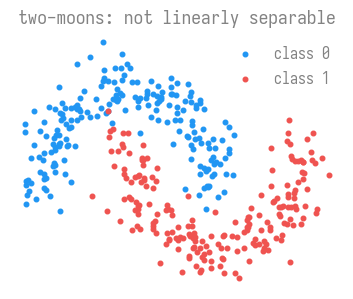

In [6]:
import numpy as np

rng = np.random.default_rng(0)

def make_moons(n=400, noise=0.15):
    """Two interleaving half-circles — the classic not-linearly-separable toy."""
    n0 = n // 2
    t0 = np.linspace(0, np.pi, n0)
    t1 = np.linspace(0, np.pi, n - n0)
    x0 = np.stack([np.cos(t0),            np.sin(t0)], 1)              # upper moon
    x1 = np.stack([1 - np.cos(t1), 1 - np.sin(t1) - 0.5], 1)         # lower moon
    X = np.concatenate([x0, x1]) + rng.normal(0, noise, (n, 2))
    y = np.concatenate([np.zeros(n0), np.ones(n - n0)]).astype(int)
    return X.astype(np.float32), y

X, y = make_moons()
plt.figure(figsize=(4.5, 3.5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=12, color=COLORS["blue"], label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=12, color=COLORS["red"], label="class 1")
plt.legend(); plt.title("two-moons: not linearly separable")
plt.xticks([]); plt.yticks([])

Now train a **tiny MLP** — just one hidden layer of 16 ReLU units — and
plot the region it assigns to each class. A single neuron (a “line”)
could only ever draw a straight cut; the hidden layer lets the network
bend the boundary:

In [7]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xt = torch.from_numpy(X)
yt = torch.from_numpy(y).float().unsqueeze(1)

# 2 inputs -> 16 hidden (ReLU) -> 1 output (probability via sigmoid).
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))
opt = torch.optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCEWithLogitsLoss()

for step in range(400):
    opt.zero_grad()
    loss = loss_fn(model(Xt), yt)
    loss.backward()
    opt.step()

acc = ((model(Xt) > 0).float() == yt).float().mean().item()
print(f"final loss = {loss.item():.3f}   train accuracy = {acc:.1%}")

final loss = 0.016   train accuracy = 99.5%

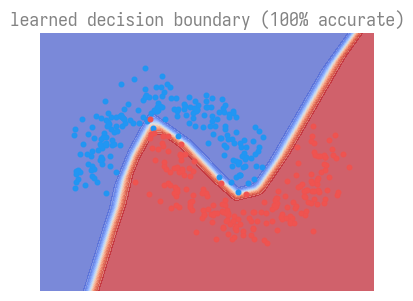

In [8]:
# Evaluate the model on a dense grid to shade its decision regions.
xx, yy = np.meshgrid(np.linspace(-1.6, 2.6, 200), np.linspace(-1.4, 1.9, 200))
grid = torch.from_numpy(np.stack([xx.ravel(), yy.ravel()], 1).astype(np.float32))
with torch.no_grad():
    zz = torch.sigmoid(model(grid)).reshape(xx.shape).numpy()

plt.figure(figsize=(4.5, 3.5))
plt.contourf(xx, yy, zz, levels=20, cmap="coolwarm", alpha=0.7)
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=12, color=COLORS["blue"])
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=12, color=COLORS["red"])
plt.title(f"learned decision boundary ({acc:.0%} accurate)")
plt.xticks([]); plt.yticks([])

The boundary is **curved** — it wraps around each crescent. That
curvature is exactly what the hidden layer + ReLU bought us; delete the
hidden layer (go straight `Linear(2, 1)`) and the best it can do is a
single straight line that gets one moon badly wrong. This is the whole
reason we stack neurons, and it scales directly to the MNIST problem
next.

The [MNIST dataset](http://yann.lecun.com/exdb/mnist/) contains
thousands of examples of handwritten numbers, with each digit labeled
0-9.

<figure>

<figcaption aria-hidden="true">MNIST Task</figcaption>
</figure>

Figure 2: A digit is just a grid of pixel intensities; the task is to
fit a function $f(\text{image}) = \text{label}$.

We’ll start with the MNIST problem in this notebook:

[📓 Fitting MNIST with a multi-layer perceptron
(MLP)](../1-mnist/index.qmd)

Next week, we’ll learn about other types of neural networks.

> **🧠 Check your understanding**
>
> Test yourself — think it through, then reveal the answer.
>
> **Q1.** How does machine learning differ from traditional programming?
>
> > **Show answer**
> >
> > In traditional programming you write explicit rules. In machine
> > learning you show the computer many examples and it **learns the
> > patterns** (the rules) on its own from the data.
>
> **Q2.** Last week’s house-price task predicted a continuous number (a
> price). The MNIST task predicts one of ten digit labels (0–9). What
> are these two kinds of problem called?
>
> > **Show answer**
> >
> > Predicting a continuous number is **regression**; predicting a
> > category label is **classification**. MNIST is a classification
> > problem.
>
> **Q3.** In the house-price example the pieces were: input, output,
> function type, loss (MSE), optimizer (SGD). Which of these must change
> for MNIST, and why?
>
> > **Show answer**
> >
> > The **output/function** (it must produce a class instead of a
> > number) and the **loss** (cross-entropy instead of MSE, since we’re
> > scoring category predictions). The overall recipe — fit a function
> > by minimizing a loss with an optimizer — stays the same.

## **References:**

- Here are some recommendations for further reading:
  - [tensorflow.org tutorials](https://www.tensorflow.org/tutorials)
  - [keras.io tutorials](https://keras.io/examples/)
  - [CS231n: Convolutional Neural Networks for Visual
    Recognition](http://cs231n.stanford.edu/)
  - [Deep Learning Specialization, Andrew
    Ng](https://www.coursera.org/specializations/deep-learning?utm_source=deeplearningai&utm_medium=institutions&utm_campaign=WebsiteCoursesDLSTopButton)
  - [PyTorch Challenge,
    Udacity](https://www.udacity.com/facebook-pytorch-scholarship)
  - [Deep Learning with
    Python](https://www.amazon.com/Deep-Learning-Python-Francois-Chollet/dp/1617294438)
  - [Keras Blog](https://blog.keras.io/)
  - [Hands-on ML
    book](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)
    with [notebooks](https://github.com/ageron/handson-ml2).